___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Keras-RL DQN Exercise


In this exercise you are going to implement your first keras-rl agent based on the **Acrobot** environment https://gymnasium.farama.org/environments/classic_control/acrobot/) <br />
The goal of this environment is to maneuver the robot arm upwards above the line with as little steps as possible

**TASK: Import necessary libraries** <br />

In [1]:
##TODO
import gymnasium as gym
import time

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import rl
from rl.agents.dqn import DQNAgent

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten , Activation
from tensorflow.keras.optimizers import Adam

In [5]:
import matplotlib.pyplot as plt
%config InlineBackened.format_figure ="retina"

**TASK: Create the environment** <br />
The name is: *Acrobot-v1*

In [6]:
##TODO
env_name = 'Acrobot-v1'

In [8]:
env = gym.make(id = env_name , render_mode = "human")
state , info = env.reset()


for _ in range(100):
    env.render()
    action = env.action_space.sample()
    env.step(action)

env.close()

In [9]:
nb_actions = env.action_space.n
nb_actions

3

In [10]:
nb_obs = env.observation_space.shape
nb_obs

(6,)

In [11]:
import pygame

In [12]:
env = gym.make("Acrobot-v1", render_mode="human")
env.reset()

action = 1  # 0 = -1 torque, 1 = no torque, 2 = +1 torque

total_reward = 0
for step in range(1000):
    # --- poll pygame events ourselves ---
    for event in pygame.event.get():
        if event.type == pygame.KEYDOWN:
            if event.key == pygame.K_LEFT:
                action = 0
            elif event.key == pygame.K_RIGHT:
                action = 2
            elif event.key == pygame.K_DOWN:
                action = 1

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    if terminated or truncated:
        print(f"Episode finished after {step+1} steps. Total reward: {total_reward}")
        break

    time.sleep(0.05)

env.close()

Episode finished after 500 steps. Total reward: -500.0


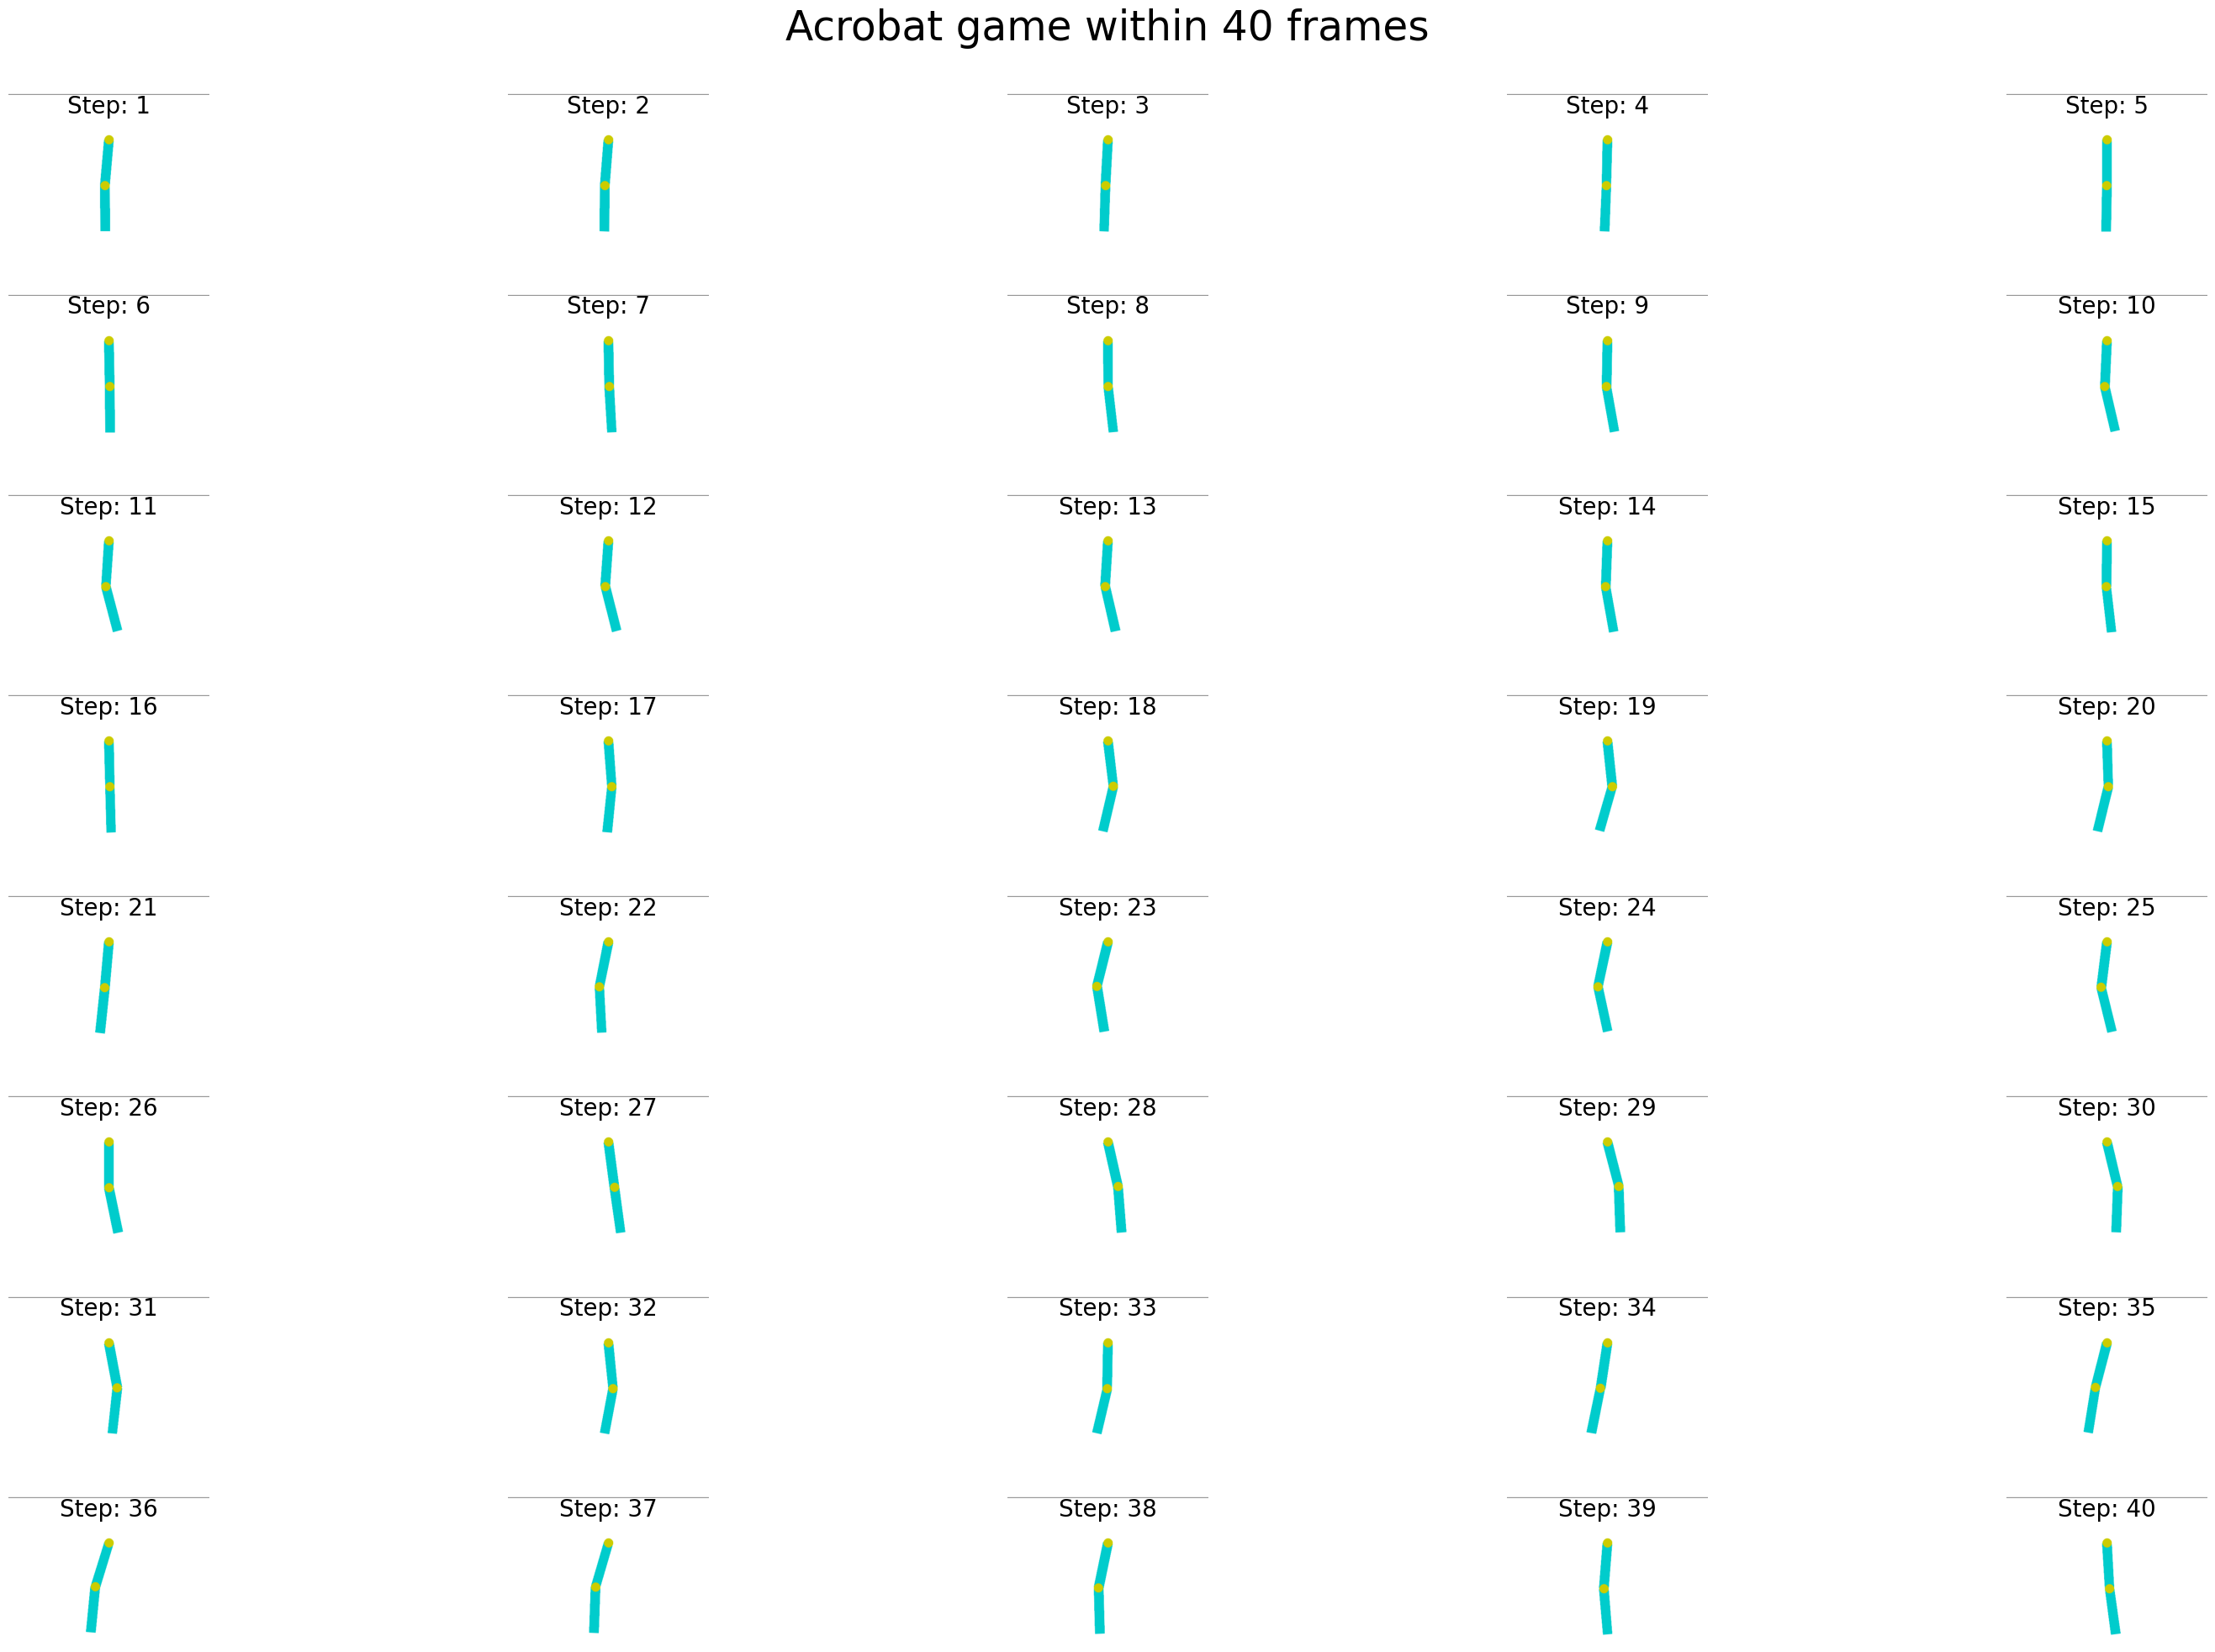

In [13]:
env2 = gym.make(id = env_name , render_mode = "rgb_array")

state2 , info2 = env2.reset()
fig , ax = plt.subplots(figsize = (30,20) , nrows = 8 , ncols = 5 , constrained_layout = True)
ax_flat = ax.flatten()

for i in range(40):
    frame = env2.render()
    action = env2.action_space.sample()
    state , reward , truncated , terminated , info = env2.step(action)

    ax_flat[i].imshow(frame)
    ax_flat[i].set_title(f"Step: {i+1}" , y = 0.6 , fontsize = 20)
    ax_flat[i].axis("off")

fig.suptitle(t = "Acrobat game within 40 frames" , fontsize = 35)
fig.tight_layout()
fig.subplots_adjust(hspace = 0.001 , wspace = .00001)
plt.show()
env2.close()

In [12]:
num_actions = env.action_space.n
num_observations = env.observation_space.shape
print(f"Action Space: {env.action_space.n}")
print(f"Observation Space: {num_observations}")

assert num_actions == 3 and num_observations == (6,) , "Wrong environment!"

Action Space: 3
Observation Space: (6,)


**TASK: Create the Neural Network for your Deep-Q-Agent** <br />
Take a look at the size of the action space and the size of the observation space.
You are free to chose any architecture you want! <br />
Hint: It already works with three layers, each having 64 neurons.

In [26]:
class OldAPIWrapper(gym.Env):
    def __init__(self, env):
        self.env = env
        self.observation_space = env.observation_space
        self.action_space = env.action_space

    def reset(self):
        obs, info = self.env.reset()
        return obs  # return only obs, not the tuple

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return obs, reward, done, info 

    def render(self , mode = "human"):
        return self.env.render()

    def close(self):
        return self.env.close()

In [27]:
env = OldAPIWrapper(gym.make(env_name))  

In [28]:
## TODO
model = Sequential()

model.add(Flatten(input_shape = (1 , num_observations[0])))
#model.add(Flatten(input_shape=(1,) + env.observation_space.shape))

model.add(Dense(units=64))
model.add(Activation(activation="relu"))

model.add(Dense(units=64))
model.add(Activation(activation="relu"))

model.add(Dense(units=64))
model.add(Activation(activation="relu"))

model.add(Dense(units=num_actions))
model.add(Activation(activation="linear"))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 6)                 0         
                                                                 
 dense_8 (Dense)             (None, 64)                448       
                                                                 
 activation_8 (Activation)   (None, 64)                0         
                                                                 
 dense_9 (Dense)             (None, 64)                4160      
                                                                 
 activation_9 (Activation)   (None, 64)                0         
                                                                 
 dense_10 (Dense)            (None, 64)                4160      
                                                                 
 activation_10 (Activation)  (None, 64)               

**TASK: Initialize the circular buffer**<br />
Make sure you set the limit appropriately (50000 works well)

In [29]:
## TODO
from rl.memory import SequentialMemory
memory = SequentialMemory(limit=50000,
                          window_length=1)

**TASK: Use the epsilon greedy action selection strategy with *decaying* epsilon**

In [30]:
## TODO
from rl.policy import LinearAnnealedPolicy , EpsGreedyQPolicy

policy = LinearAnnealedPolicy(inner_policy = EpsGreedyQPolicy(),
                              attr = "eps",
                              value_max = 1 ,
                              value_min = 0.1 , 
                              value_test = 0.05 , 
                              nb_steps = 20000
                             )

**TASK: Create the DQNAgent** <br />
Feel free to play with the nb_steps_warump, target_model_update, batch_size and gamma parameters. <br />
Hint:<br />
You can try *nb_steps_warmup*=1000, *target_model_update*=1000, *batch_size*=32 and *gamma*=0.99 as a first guess

In [31]:
## TODO
dqn = DQNAgent(model = model , 
               nb_actions = num_actions ,
               memory = memory , 
               nb_steps_warmup = 10 , 
               target_model_update = 100 ,
               policy = policy
              )

**TASK: Compile the model** <br />
Feel free to explore the effects of different optimizers and learning rates.
You can try Adam with a learning rate of 1e-3 as a first guess 

In [32]:
## TODO
dqn.compile(optimizer = Adam(learning_rate=1e-3) , metrics = ["mae"])

**TASK: Fit the model** <br />
150,000 steps should be a very good starting point

In [33]:
## TODO
dqn.fit(env,
        nb_steps = 150000,
        visualize=False,
        verbose=2
       )

Training for 150000 steps ...
    500/150000: episode: 1, duration: 2.990s, episode steps: 500, steps per second: 167, episode reward: -500.000, mean reward: -1.000 [-1.000, -1.000], mean action: 0.942 [0.000, 2.000],  loss: 0.039471, mae: 1.743129, mean_q: -2.465043, mean_eps: 0.988525
   1000/150000: episode: 2, duration: 2.884s, episode steps: 500, steps per second: 173, episode reward: -500.000, mean reward: -1.000 [-1.000, -1.000], mean action: 0.990 [0.000, 2.000],  loss: 0.060664, mae: 4.827825, mean_q: -7.070450, mean_eps: 0.966273
   1500/150000: episode: 3, duration: 2.656s, episode steps: 500, steps per second: 188, episode reward: -500.000, mean reward: -1.000 [-1.000, -1.000], mean action: 0.974 [0.000, 2.000],  loss: 0.106372, mae: 7.640143, mean_q: -11.251937, mean_eps: 0.943773
   2000/150000: episode: 4, duration: 2.533s, episode steps: 500, steps per second: 197, episode reward: -500.000, mean reward: -1.000 [-1.000, -1.000], mean action: 1.024 [0.000, 2.000],  loss: 

**TASK: Evaluate the model**

In [34]:
## TODO
env = OldAPIWrapper(gym.make(env_name, render_mode="human"))

In [35]:
dqn.test(env, nb_episodes=5, visualize=True)
env.close()

Testing for 5 episodes ...
Episode 1: reward: -69.000, steps: 70
Episode 2: reward: -98.000, steps: 99
Episode 3: reward: -78.000, steps: 79
Episode 4: reward: -70.000, steps: 71
Episode 5: reward: -69.000, steps: 70
